# Análisis de Datos II — Actividad 1: Interpretabilidad de modelos

**Dataset:** [Data Science Salaries 2023](https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023)


## 1. Carga del dataset

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

In [2]:
DATA_PATH = "data/ds_salaries.csv"

df = pd.read_csv(DATA_PATH)
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 3755  |  Columnas: 11


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


### 1.1 Estructura y tipos de datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


**OBSERVACIONES**
- Hay 11 variables, de las cuales 4 son numéricas y 7, categóricas.
- La variable objetivo es `salary_in_usd` y representa el sueldo anual bruto expresado en dólares.
- La variable `salary` representa el equivalente a `salary_in_usd`pero expresado en moneda local. Esto implica alto riesgo de *data leakage*.

### 1.2 Valores faltantes y duplicados

In [4]:
print("Valores nulos por columna:")
print(df.isna().sum())
print()
print("Filas duplicadas:", df.duplicated().sum())

Valores nulos por columna:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Filas duplicadas: 1171


### 1.3 Variables numéricas y categóricas

In [5]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
work_year,3755.0,2022.373635,0.691448,2020.0,2022.0,2022.0,2023.0,2023.0
salary,3755.0,190695.571771,671676.500508,6000.0,100000.0,138000.0,180000.0,30400000.0
salary_in_usd,3755.0,137570.389880,63055.625278,5132.0,95000.0,135000.0,175000.0,450000.0
remote_ratio,3755.0,46.271638,48.589050,0.0,0.0,0.0,100.0,100.0


In [6]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

resumen = pd.DataFrame({
    "n_unicos": df[cat_cols].nunique(),
    "top": df[cat_cols].mode().iloc[0],
    "freq_top": [df[col].value_counts().iloc[0] for col in cat_cols],
})
resumen

,n_unicos,top,freq_top
experience_level,4,SE,2516
employment_type,4,FT,3718
job_title,93,Data Engineer,1040
salary_currency,20,USD,3224
employee_residence,78,US,3004
company_location,72,US,3040
company_size,3,M,3153


**OBSERVACIONES**
- Algunas de las variables categóricas como `job_title`, `employee_residence` y `company_location` presentan alta cardinalidad.

In [7]:
df["salary_in_usd"].describe()

count      3755.000000
mean     137570.389880
std       63055.625278
min        5132.000000
25%       95000.000000
50%      135000.000000
75%      175000.000000
max      450000.000000
Name: salary_in_usd, dtype: float64

## 2. EDA

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Paleta de un solo tono (azul) + tinta recesiva para ejes y grilla
AZUL = "#2a78d6"
RAMPA = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]  # ordinal: claro -> oscuro
TINTA, TINTA_SEC, GRILLA = "#0b0b0b", "#52514e", "#e6e5e1"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRILLA,
    "axes.labelcolor": TINTA_SEC,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlecolor": TINTA,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRILLA,
    "grid.linewidth": 0.8,
    "xtick.color": TINTA_SEC,
    "ytick.color": TINTA_SEC,
    "font.size": 9,
})


def miles_usd(x, _):
    return f"${x/1000:,.0f}k"

### 2.1 Distribución del target

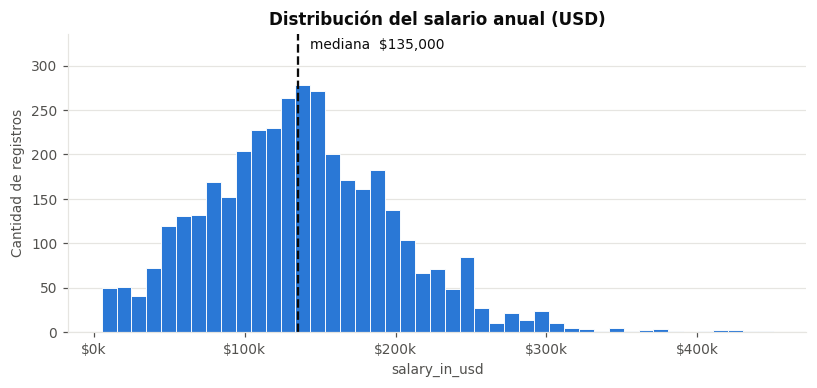

Asimetría (skew): 0.54


In [9]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))

ax.hist(df["salary_in_usd"], bins=45, color=AZUL, edgecolor="white", linewidth=0.6)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

mediana = df["salary_in_usd"].median()
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)   # aire para la etiqueta
ax.axvline(mediana, color=TINTA, linewidth=1.5, linestyle="--")
ax.annotate(f"mediana  ${mediana:,.0f}", xy=(mediana, ax.get_ylim()[1]),
            xytext=(8, -10), textcoords="offset points", color=TINTA, fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(miles_usd))
ax.set_title("Distribución del salario anual (USD)")
ax.set_xlabel("salary_in_usd")
ax.set_ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

print(f"Asimetría (skew): {df['salary_in_usd'].skew():.2f}")

**OBSERVACIONES**
- Distribución unimodal, levemente asimétrica a la derecha, acotada en $450k USD.

### 2.2 Salario por nivel de experiencia y por año

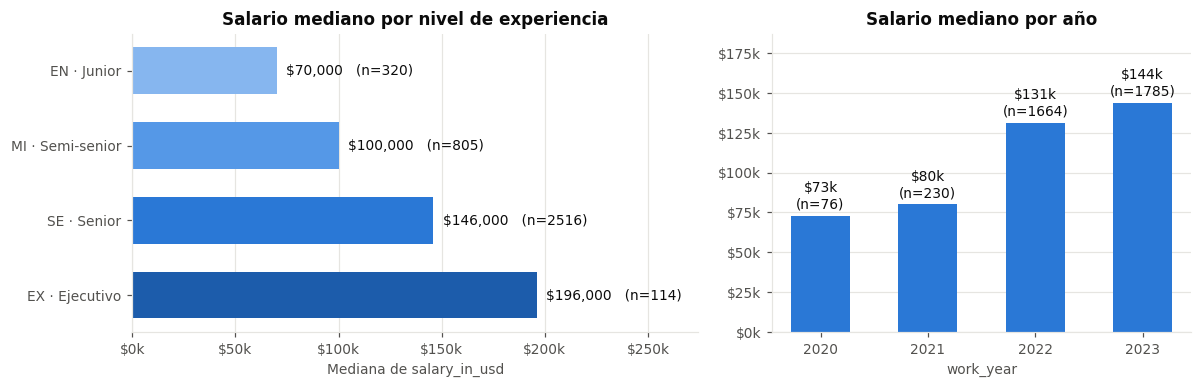

In [10]:
ORDEN_EXP = ["EN", "MI", "SE", "EX"]
ETIQUETAS_EXP = {"EN": "EN · Junior", "MI": "MI · Semi-senior",
                 "SE": "SE · Senior", "EX": "EX · Ejecutivo"}

exp = (df.groupby("experience_level")["salary_in_usd"]
         .agg(mediana="median", n="size")
         .reindex(ORDEN_EXP))

anio = (df.groupby("work_year")["salary_in_usd"]
          .agg(mediana="median", n="size"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6),
                               gridspec_kw={"width_ratios": [1.35, 1]})

# --- Izquierda: mediana por nivel de experiencia (rampa ordinal)
y = range(len(exp))
ax1.barh(y, exp["mediana"], color=RAMPA, height=0.62)
ax1.set_yticks(list(y), [ETIQUETAS_EXP[i] for i in exp.index])
ax1.invert_yaxis()
ax1.grid(axis="y", visible=False)
ax1.set_axisbelow(True)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(miles_usd))
for i, (val, n) in enumerate(zip(exp["mediana"], exp["n"])):
    ax1.annotate(f"${val:,.0f}   (n={n})", xy=(val, i), xytext=(6, 0),
                 textcoords="offset points", va="center", fontsize=9, color=TINTA)
ax1.set_xlim(0, exp["mediana"].max() * 1.4)
ax1.set_title("Salario mediano por nivel de experiencia")
ax1.set_xlabel("Mediana de salary_in_usd")

# --- Derecha: mediana por año
ax2.bar(anio.index.astype(str), anio["mediana"], color=AZUL, width=0.55)
ax2.grid(axis="x", visible=False)
ax2.set_axisbelow(True)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(miles_usd))
for x, (val, n) in enumerate(zip(anio["mediana"], anio["n"])):
    ax2.annotate(f"${val/1000:,.0f}k" + "\n" + f"(n={n})", xy=(x, val), xytext=(0, 5),
                 textcoords="offset points", ha="center", fontsize=9, color=TINTA)
ax2.set_ylim(0, anio["mediana"].max() * 1.3)
ax2.set_title("Salario mediano por año")
ax2.set_xlabel("work_year")

plt.tight_layout()
plt.show()

**OBSERVACIONES**
- El salario crece de forma monótona con el señority, lo cual es esperable.
- El salario crece de forma monótona con el año. Podría ser razonable en un contexto de mayor requerimiento de recursos humanos con este tipo de formación.

### 2.3 Variables de alta cardinalidad

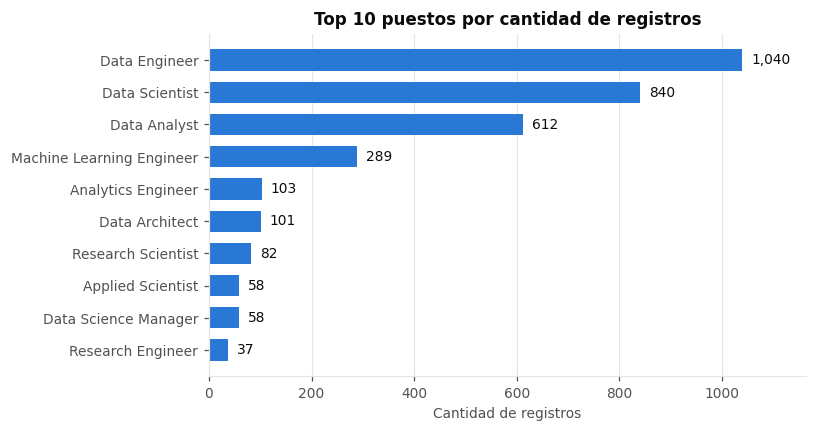

Los 10 puestos más frecuentes cubren el 85.8% de los registros (sobre 93 puestos distintos).
Registros con company_location == 'US': 81.0%


In [11]:
top_titles = df["job_title"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.barh(top_titles.index, top_titles.values, color=AZUL, height=0.66)
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
for i, val in enumerate(top_titles.values):
    ax.annotate(f"{val:,}", xy=(val, i), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color=TINTA)
ax.set_xlim(0, top_titles.max() * 1.12)
ax.set_title("Top 10 puestos por cantidad de registros")
ax.set_xlabel("Cantidad de registros")
plt.tight_layout()
plt.show()

cobertura = top_titles.sum() / len(df)
print(f"Los 10 puestos más frecuentes cubren el {cobertura:.1%} de los registros "
      f"(sobre {df['job_title'].nunique()} puestos distintos).")
print(f"Registros con company_location == 'US': {(df['company_location'] == 'US').mean():.1%}")

### 2.4 Verificación de la sospecha de leakage

In [12]:
pct_usd = (df["salary_currency"] == "USD").mean()
corr_global = df["salary"].corr(df["salary_in_usd"])
sub_usd = df[df["salary_currency"] == "USD"]
corr_usd = sub_usd["salary"].corr(sub_usd["salary_in_usd"])
identicos = (sub_usd["salary"] == sub_usd["salary_in_usd"]).mean()

print(f"Registros con salary_currency == 'USD' : {pct_usd:.1%}")
print(f"corr(salary, salary_in_usd) global      : {corr_global:.3f}")
print(f"corr(salary, salary_in_usd) solo USD    : {corr_usd:.3f}")
print(f"Filas USD donde salary == salary_in_usd : {identicos:.1%}")

Registros con salary_currency == 'USD' : 85.9%
corr(salary, salary_in_usd) global      : -0.024
corr(salary, salary_in_usd) solo USD    : 1.000
Filas USD donde salary == salary_in_usd : 100.0%


**OBSERVACIONES**
- En la gran mayoría de los registros la moneda ya es USD y ahí `salary` es literalmente el target.
- La correlación global es baja sólo porque las monedas de valor nominal muy distinto la ensucian, dentro de una
misma moneda la relación es perfecta (correlación 1).
- `salary` es una copia del target y el modelo va a poder leerla directamente.

### 2.5 Matriz de correlación

In [13]:
from matplotlib.colors import LinearSegmentedColormap

# Divergente azul <-> rojo con punto medio gris neutro (el 0 no debe "leerse" como color)
CMAP_DIV = LinearSegmentedColormap.from_list("div_br", [
    "#0d366b", "#1c5cab", "#2a78d6", "#86b6ef", "#cde2fb",
    "#f0efec",
    "#f7c9c8", "#ef9291", "#e34948", "#b83433", "#8a2726",
])
# Secuencial de un solo tono para magnitudes sin signo
CMAP_SEQ = LinearSegmentedColormap.from_list("seq_blue", [
    "#f0efec", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
    "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#0d366b",
])


def heatmap(matriz, ax, cmap, vmin, vmax, umbral_texto, titulo):
    """Dibuja una matriz cuadrada etiquetando el valor dentro de cada celda."""
    im = ax.imshow(matriz.values, cmap=cmap, vmin=vmin, vmax=vmax)
    etiquetas = matriz.columns
    ax.set_xticks(range(len(etiquetas)), etiquetas, rotation=45, ha="right")
    ax.set_yticks(range(len(etiquetas)), etiquetas)
    ax.grid(False)
    # separación entre celdas, del color de la superficie
    ax.set_xticks([i - 0.5 for i in range(len(etiquetas) + 1)], minor=True)
    ax.set_yticks([i - 0.5 for i in range(len(etiquetas) + 1)], minor=True)
    ax.tick_params(which="minor", length=0)
    ax.grid(which="minor", color="white", linewidth=2)
    for spine in ax.spines.values():
        spine.set_visible(False)
    for i in range(len(etiquetas)):
        for j in range(len(etiquetas)):
            v = matriz.values[i, j]
            ax.annotate(f"{v:.2f}", (j, i), ha="center", va="center", fontsize=8,
                        color="white" if abs(v) > umbral_texto else TINTA)
    ax.set_title(titulo)
    return im

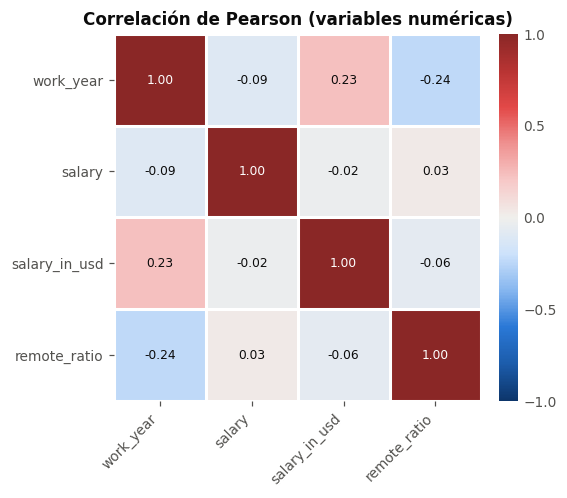

In [14]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
pearson = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(5.4, 4.6))
im = heatmap(pearson, ax, CMAP_DIV, -1, 1, 0.6,
             "Correlación de Pearson (variables numéricas)")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[-1, -0.5, 0, 0.5, 1])
cb.outline.set_visible(False)
cb.ax.tick_params(length=0)
plt.tight_layout()
plt.show()

**OBSERVACIONES**
- Se observa una correlación lineal entre `salary` vs `salary_in_usd` prácticamente nula.
- Una baja correlación es condición necesaria pero no suficiente para garantizar que no hay *data leakage*.

#### 2.6 Matriz de asociación

Para cubrir también las categóricas, se usa una medida por tipo de par, todas normalizadas
al rango [0, 1]:

| Tipo de par | Medida |
|---|---|
| numérica ↔ numérica | \|Spearman\| (monotónica, robusta a las escalas mezcladas de `salary`) |
| numérica ↔ categórica | razón de correlación η |
| categórica ↔ categórica | V de Cramér con corrección de sesgo |

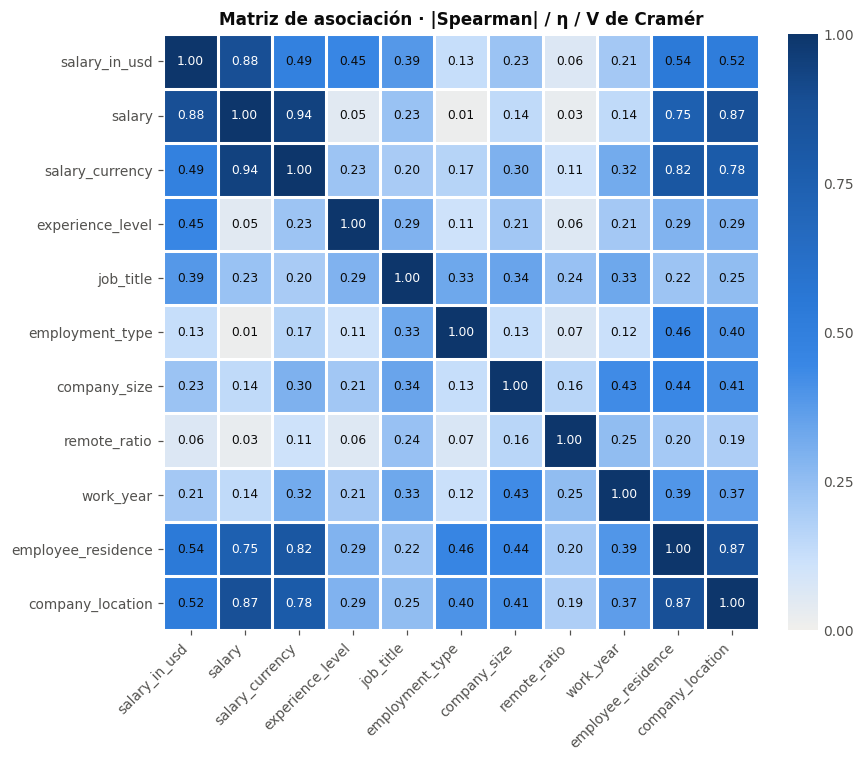

In [15]:
from scipy.stats import chi2_contingency


def cramers_v(x, y):
    """V de Cramér con corrección de sesgo (Bergsma, 2013)."""
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla, correction=False)[0]
    n = tabla.values.sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    phi2_corr = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0


def razon_correlacion(categorias, valores):
    """Razón de correlación η: qué parte de la varianza numérica explica la categórica."""
    media_global = valores.mean()
    ss_entre = sum(
        len(g) * (g.mean() - media_global) ** 2
        for _, g in valores.groupby(categorias, observed=True)
    )
    ss_total = ((valores - media_global) ** 2).sum()
    return np.sqrt(ss_entre / ss_total) if ss_total > 0 else 0.0


ORDEN_VARS = ["salary_in_usd", "salary", "salary_currency", "experience_level",
              "job_title", "employment_type", "company_size", "remote_ratio",
              "work_year", "employee_residence", "company_location"]

es_num = {c: c in num_cols for c in ORDEN_VARS}
asoc = pd.DataFrame(np.zeros((len(ORDEN_VARS), len(ORDEN_VARS))),
                    index=ORDEN_VARS, columns=ORDEN_VARS)

for a in ORDEN_VARS:
    for b in ORDEN_VARS:
        if a == b:
            asoc.loc[a, b] = 1.0
        elif es_num[a] and es_num[b]:
            asoc.loc[a, b] = abs(df[a].corr(df[b], method="spearman"))
        elif es_num[a] and not es_num[b]:
            asoc.loc[a, b] = razon_correlacion(df[b], df[a])
        elif not es_num[a] and es_num[b]:
            asoc.loc[a, b] = razon_correlacion(df[a], df[b])
        else:
            asoc.loc[a, b] = cramers_v(df[a], df[b])

fig, ax = plt.subplots(figsize=(8.2, 7))
im = heatmap(asoc, ax, CMAP_SEQ, 0, 1, 0.55,
             "Matriz de asociación · |Spearman| / η / V de Cramér")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 0.25, 0.5, 0.75, 1])
cb.outline.set_visible(False)
cb.ax.tick_params(length=0)
plt.tight_layout()
plt.show()

In [16]:
pares = (asoc.where(np.triu(np.ones(asoc.shape), k=1).astype(bool))
             .stack()
             .sort_values(ascending=False)
             .head(8)
             .rename("asociación")
             .reset_index()
             .rename(columns={"level_0": "variable A", "level_1": "variable B"}))

mismo_pais = (df["employee_residence"] == df["company_location"]).mean()
print(f"Filas donde employee_residence == company_location: {mismo_pais:.1%}")
print()
pares

Filas donde employee_residence == company_location: 97.4%



,variable A,variable B,asociación
0,salary,salary_currency,0.943748
1,salary_in_usd,salary,0.883910
2,salary,company_location,0.874946
3,employee_residence,company_location,0.871204
4,salary_currency,employee_residence,0.818632
5,salary_currency,company_location,0.782736
6,salary,employee_residence,0.745691
7,salary_in_usd,employee_residence,0.538749


**OBSERVACIONES**
1. **`employee_residence` ↔ `company_location` (V de Cramér 0,87)**. El par de categóricas
   más asociado del dataset. Es información prácticamente duplicada: nos dice que, salvo excepciones, la
   gente vive donde está radicada la empresa. Dos variables de alta cardinalidad diciendo
   casi lo mismo van a **repartirse la importancia** entre sí y a diluir su peso en el PFI.
2. **`salary_currency` ↔ geografía (0,82 y 0,78)**. Mismo que lo anterior: la moneda es una
   consecuencia del país. Es un tercer proxy de la misma dimensión.
3. **`salary` ↔ `salary_in_usd` con Spearman: 0,88**, contra el −0,02 de Pearson. La
   relación monotónica sí es fuerte, y confirma desde otro ángulo lo de visto anteriormente. Además
   `salary` ↔ `salary_currency` da 0,94 (η): la moneda explica casi toda la varianza de
   `salary`, que es exactamente lo que rompía a Pearson.
4. **`experience_level` (0,45) y `job_title` (0,39) frente al target** — asociación
   moderada. Son las variables con señal genuina.

**CONCLUSIONES**

- *data leakage* en `salary`.
- Grupo de variables redundantes (residencia / ubicación / moneda).
- `experience_level`y `job_title` tiene una relación moredada con la variable target. Tiene sentido que haya relación entre la experiencia y el sueldo así como con el tipo de trabajo.

## 3. Entrenamiento

### 3.1 Preparación de los datos

Las 7 categóricas se codifican con `OrdinalEncoder` manteniendo constante la cantidad de features.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

TARGET = "salary_in_usd"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

cat_features = X.select_dtypes(include="object").columns.tolist()
num_features = X.select_dtypes(include=np.number).columns.tolist()

# Para las dos categóricas con orden natural, se respeta ese orden en la codificación;
# el resto queda en orden alfabético de forma arbitraria 
# (no influye en el árbol, que puede aislar categorías con cortes sucesivos).

CATEGORIAS = []
for col in cat_features:
    if col == "experience_level":
        CATEGORIAS.append(np.array(["EN", "MI", "SE", "EX"], dtype=object))
    elif col == "company_size":
        CATEGORIAS.append(np.array(["S", "M", "L"], dtype=object))
    else:
        CATEGORIAS.append(np.array(sorted(X[col].unique()), dtype=object))

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE)

# Encoder categorical variables
encoder = OrdinalEncoder(categories=CATEGORIAS,
                         handle_unknown="use_encoded_value", unknown_value=-1)
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()
X_train_enc[cat_features] = encoder.fit_transform(X_train[cat_features])
X_test_enc[cat_features] = encoder.transform(X_test[cat_features])

print(f"Features ({X.shape[1]}): {num_features} + {cat_features}")
print(f"Train: {X_train_enc.shape[0]} filas  |  Test: {X_test_enc.shape[0]} filas")
X_train_enc.head()

Features (10): ['work_year', 'salary', 'remote_ratio'] + ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']
Train: 2628 filas  |  Test: 1127 filas


,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size
2080,2022,2.0,2.0,33.0,144000,19.0,75.0,100,70.0,1.0
2566,2022,2.0,2.0,25.0,89200,19.0,75.0,100,70.0,1.0
887,2023,1.0,2.0,33.0,125000,19.0,75.0,0,70.0,1.0
2669,2022,2.0,2.0,25.0,81666,19.0,75.0,100,70.0,1.0
685,2023,1.0,2.0,33.0,162500,19.0,75.0,0,70.0,1.0


### 3.2 Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_enc, y_train)

print(rf)

RandomForestRegressor(n_jobs=-1, random_state=42)


### 3.3 Evaluación

Se reportan:
- **MAE**: error típico en dólares, fácil de leer.
- **RMSE**: penaliza los errores grandes.
- **R²**: proporción de varianza explicada. 

Como baseline se agrega un modelo trivial que siempre predice la mediana del train.

In [19]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


def metricas(y_real, y_pred):
    return {
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": root_mean_squared_error(y_real, y_pred),
        "R2": r2_score(y_real, y_pred),
    }


dummy = DummyRegressor(strategy="median").fit(X_train_enc, y_train)

pred_train = rf.predict(X_train_enc)
pred_test = rf.predict(X_test_enc)

resultados = pd.DataFrame({
    "Baseline · test": metricas(y_test, dummy.predict(X_test_enc)),
    "Random Forest · train": metricas(y_train, pred_train),
    "Random Forest · test": metricas(y_test, pred_test),
}).T
resultados.style.format({"MAE": "${:,.0f}", "RMSE": "${:,.0f}", "R2": "{:.3f}"})

,MAE,RMSE,R2
Baseline · test,"$48,412","$62,990",-0.001
Random Forest · train,$533,"$3,467",0.997
Random Forest · test,"$1,929","$16,717",0.930


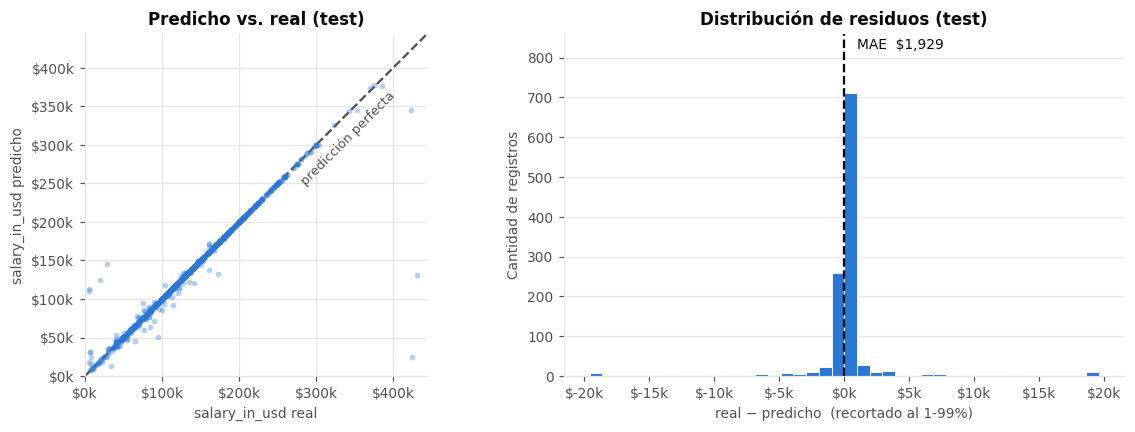

Predicciones con error <= $10.000: 97.2% del test
Residuos fuera del rango graficado: 17 de 1127


In [20]:
residuos = y_test - pred_test

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# --- Izquierda: predicho vs real
lim = [0, max(y_test.max(), pred_test.max()) * 1.03]
ax1.plot(lim, lim, color=TINTA_SEC, linewidth=1.5, linestyle="--", zorder=1)
ax1.scatter(y_test, pred_test, s=14, color=AZUL, alpha=0.35, linewidths=0, zorder=2)
ax1.annotate("predicción perfecta", xy=(lim[1] * 0.62, lim[1] * 0.62),
             xytext=(6, -14), textcoords="offset points",
             fontsize=8.5, color=TINTA_SEC, rotation=45, rotation_mode="anchor")
ax1.set_xlim(lim)
ax1.set_ylim(lim)
ax1.set_aspect("equal")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(miles_usd))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(miles_usd))
ax1.set_axisbelow(True)
ax1.set_title("Predicho vs. real (test)")
ax1.set_xlabel("salary_in_usd real")
ax1.set_ylabel("salary_in_usd predicho")

# --- Derecha: distribución de residuos
lo, hi = np.percentile(residuos, [1, 99])
margen = max(abs(lo), abs(hi)) * 1.1
ax2.hist(np.clip(residuos, -margen, margen), bins=40, range=(-margen, margen),
         color=AZUL, edgecolor="white", linewidth=0.6)
ax2.set_ylim(0, ax2.get_ylim()[1] * 1.15)
ax2.axvline(0, color=TINTA, linewidth=1.5, linestyle="--")
ax2.annotate(f"MAE  ${np.abs(residuos).mean():,.0f}", xy=(0, ax2.get_ylim()[1]),
             xytext=(8, -10), textcoords="offset points", color=TINTA, fontsize=9)
ax2.grid(axis="x", visible=False)
ax2.set_axisbelow(True)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(miles_usd))
ax2.set_title("Distribución de residuos (test)")
ax2.set_xlabel("real − predicho  (recortado al 1-99%)")
ax2.set_ylabel("Cantidad de registros")

plt.tight_layout()
plt.show()

dentro_10k = (np.abs(residuos) <= 10_000).mean()
print(f"Predicciones con error <= $10.000: {dentro_10k:.1%} del test")
print(f"Residuos fuera del rango graficado: {(np.abs(residuos) > margen).sum()} de {len(residuos)}")

**OBSERVACIONES**
- El modelo alcanza **R² = 0,930** en test con un **MAE de $1.929**, contra los $48.412 del
  baseline que predice siempre la mediana. 
- El 97,2% de las predicciones cae a menos de $10.000 del valor real.
- La nube de predicho vs. real cae prácticamente sobre la diagonal y los residuos se
  concentran en un pico angosto alrededor de 0.
  - Un desempeño tan bueno para predecir salarios es sospechoso: en un problema con esta
  cantidad de ruido (dos personas con el mismo puesto, país y seniority cobran distinto)
  es imposible acertar el sueldo casi exacto. Esto reafirma la hipótesis de *data leakage* ya
  detectada en el EDA: el modelo no está prediciendo, está leyendo `salary`.
- La brecha train/test es chica (R² 0,997 vs 0,930), así que no es sobreajuste clásico:
  la señal que explota está igual de disponible en test.
- El dataset tiene 1.171 filas duplicadas que el split reparte entre train y test, lo que infla algo las métricas.

## 4. Diagnóstico global (PFI)

Se aplica sobre el MAE, por lo que, mientras más bajo, mejor.

In [21]:
from sklearn.inspection import permutation_importance

pfi = permutation_importance(
    rf, X_test_enc, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="neg_mean_absolute_error",
)

importancias = (pd.DataFrame({
        "variable": X_test_enc.columns,
        "importancia": pfi.importances_mean,
        "desvio": pfi.importances_std,
    })
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True))

importancias.style.format({"importancia": "${:,.0f}", "desvio": "${:,.0f}"})

,variable,importancia,desvio
0,salary,"$64,648",$853
1,salary_currency,"$9,922",$529
2,employee_residence,$251,$34
3,company_location,$245,$29
4,work_year,$70,$12
5,company_size,$26,$9
6,employment_type,$22,$11
7,job_title,$17,$20
8,experience_level,$15,$11
9,remote_ratio,$6,$6


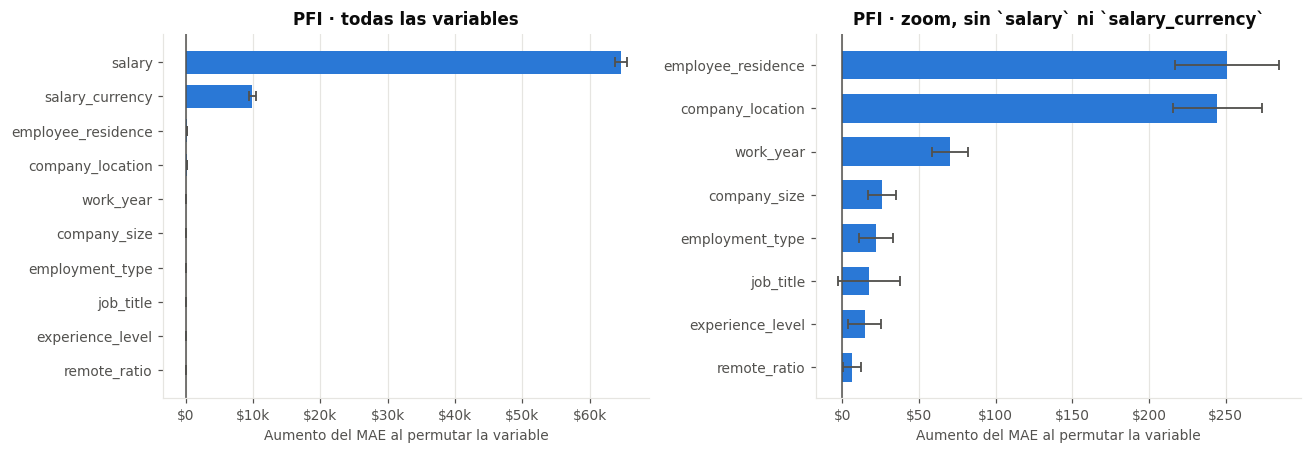

salary + salary_currency concentran el 99.1% de la importancia total


In [22]:
ROJO = "#e34948"  # importancia negativa: permutar la variable *mejora* al modelo


def fmt_dolares(x, _):
    """Miles con sufijo k, o dólares enteros cuando la escala es chica (panel de zoom)."""
    return f"${x/1000:,.0f}k" if abs(x) >= 1000 else f"${x:,.0f}"


def grafico_pfi(tabla, ax, titulo):
    tabla = tabla.sort_values("importancia")
    colores = [AZUL if v >= 0 else ROJO for v in tabla["importancia"]]
    ax.barh(tabla["variable"], tabla["importancia"], color=colores, height=0.66,
            xerr=tabla["desvio"], error_kw={"ecolor": TINTA_SEC, "elinewidth": 1.2,
                                           "capsize": 3, "capthick": 1.2})
    ax.axvline(0, color=TINTA_SEC, linewidth=1)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_dolares))
    ax.set_title(titulo)
    ax.set_xlabel("Aumento del MAE al permutar la variable")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

grafico_pfi(importancias, ax1, "PFI · todas las variables")

# El segundo panel repite el análisis sin las dos variables que dominan la escala:
# de otro modo el resto de las barras es invisible.
resto = importancias[~importancias["variable"].isin(["salary", "salary_currency"])]
grafico_pfi(resto, ax2, "PFI · zoom, sin `salary` ni `salary_currency`")

plt.tight_layout()
plt.show()

total = importancias["importancia"].clip(lower=0).sum()
peso_leak = importancias.loc[
    importancias["variable"].isin(["salary", "salary_currency"]), "importancia"].sum()
print(f"salary + salary_currency concentran el {peso_leak / total:.1%} de la importancia total")

**OBSERVACIONES**
- `salary` domina por completo: permutarla degrada el MAE en **~$64.600**, es decir que el
  modelo pasa de errar $1.929 a errar más que el baseline de la mediana. Junto con
  `salary_currency` (~$9.900) concentran el **99,1%** de la importancia total.
- Se confirma el *data leakage*   anticipado en el EDA.
- Las variables con sentido de negocio quedan en la nada. Por ejemplo, 
  `experience_level` aporta **$15 ± $11** y `job_title` **$17 ± $20** — en ambos casos el
  desvío es del orden de la media, así que su importancia es estadísticamente
  indistinguible de cero. Es un resultado absurdo para un modelo de salarios, y contradice
  de plano el EDA, donde `experience_level` mostraba una asociación de 0,45 con el target y
  el salario mediano iba de $70k (EN) a $196k (EX). La explicación es que, teniendo
  `salary`, el modelo no necesita mirar nada más.
- `employee_residence` ($251) y `company_location` ($245) encabezan el resto, pero con
  desvíos altos en relación a su media. Es consistente con la redundancia detectada en la
  matriz de asociación (V de Cramér 0,87, 97,4% de filas con el mismo país): al permutar
  una, la otra sigue aportando la misma información y el modelo casi no se degrada.

## 5. Diagnóstico local (SHAP)

Se usa `TreeExplainer`, que calcula los valores de Shapley de forma exacta para modelos
de árboles.

In [23]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test_enc)

shap_display = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_test.values,
    feature_names=list(X_test.columns),
)

print(f"Valores SHAP: {shap_values.values.shape[0]} observaciones x "
      f"{shap_values.values.shape[1]} variables")
print(f"E[f(X)] (predicción media del modelo): ${shap_values.base_values[0]:,.0f}")

Valores SHAP: 1127 observaciones x 10 variables
E[f(X)] (predicción media del modelo): $137,983


### 5.1 Vista de conjunto


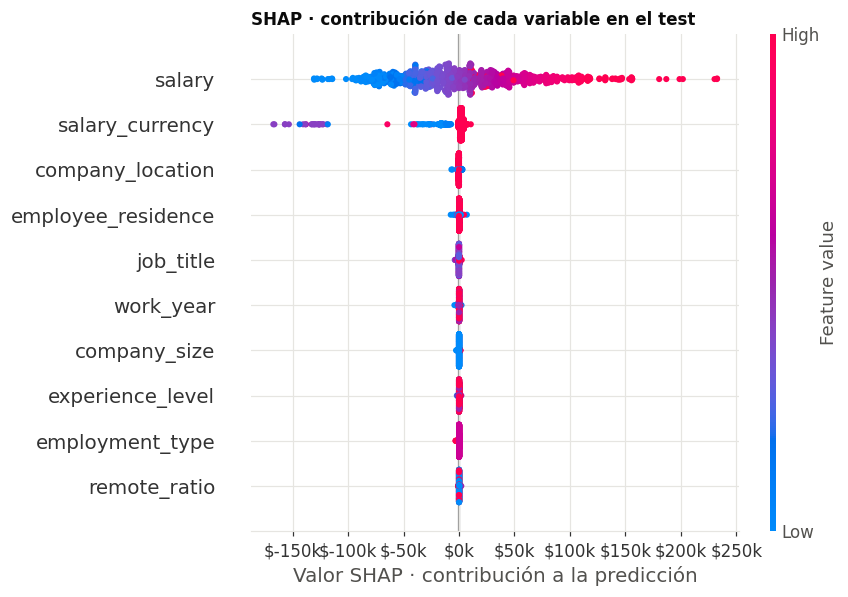

In [24]:
plt.figure()
shap.plots.beeswarm(shap_values, max_display=10, show=False)
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(miles_usd)) 
ax.set_xlabel("Valor SHAP · contribución a la predicción")
plt.title("SHAP · contribución de cada variable en el test", fontsize=11,
          fontweight="bold", color=TINTA, loc="left")
plt.tight_layout()
plt.show()

In [25]:
i_alta = int(np.argmax(pred_test))
i_baja = int(np.argmin(pred_test))

casos = pd.DataFrame({
    "Predicción ALTA": X_test.iloc[i_alta],
    "Predicción BAJA": X_test.iloc[i_baja],
})
casos.loc["— predicción del modelo"] = [pred_test[i_alta], pred_test[i_baja]]
casos.loc["— valor real"] = [y_test.iloc[i_alta], y_test.iloc[i_baja]]
casos.loc["— error"] = [y_test.iloc[i_alta] - pred_test[i_alta],
                        y_test.iloc[i_baja] - pred_test[i_baja]]
casos

,Predicción ALTA,Predicción BAJA
work_year,2022,2023
experience_level,SE,EN
employment_type,FT,FT
job_title,Data Science Tech Lead,Autonomous Vehicle Technician
salary,375000,7000
salary_currency,USD,USD
employee_residence,US,GH
remote_ratio,50,0
company_location,US,GH
company_size,L,S


#### Caso A · predicción alta

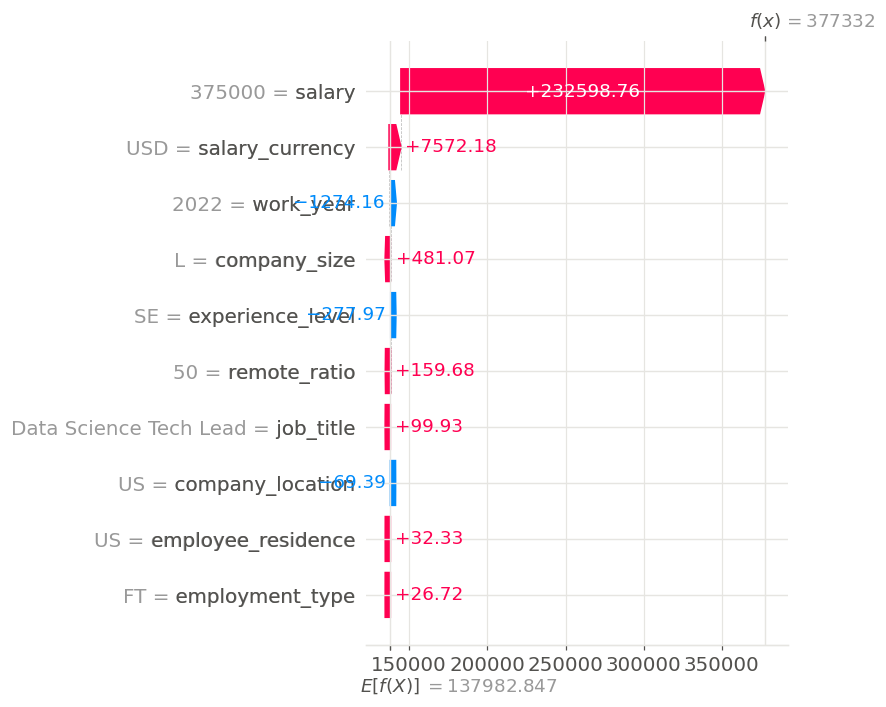

In [26]:
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_display[i_alta], max_display=11, show=False)
plt.tight_layout()
plt.show()

#### Caso B · predicción baja

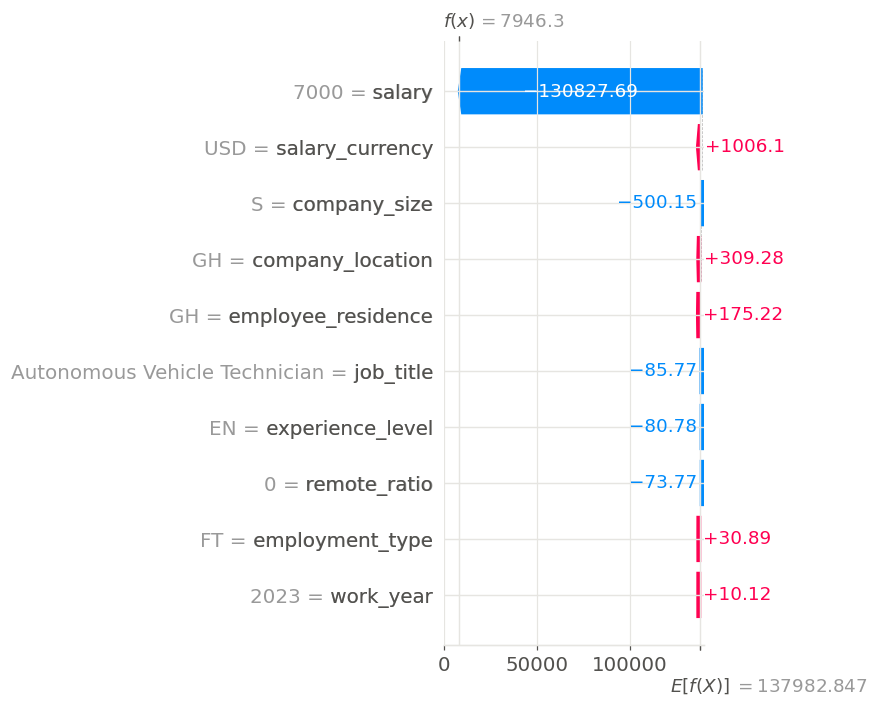

In [27]:
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_display[i_baja], max_display=11, show=False)
plt.tight_layout()
plt.show()

In [28]:
# Contribución de cada variable en los dos casos, lado a lado
comparacion = pd.DataFrame({
    "variable": X_test.columns,
    "valor (caso A)": X_test.iloc[i_alta].values,
    "SHAP (caso A)": shap_values.values[i_alta],
    "valor (caso B)": X_test.iloc[i_baja].values,
    "SHAP (caso B)": shap_values.values[i_baja],
})
comparacion["|SHAP| total"] = (comparacion["SHAP (caso A)"].abs()
                               + comparacion["SHAP (caso B)"].abs())
comparacion = (comparacion.sort_values("|SHAP| total", ascending=False)
                          .drop(columns="|SHAP| total")
                          .reset_index(drop=True))
comparacion.style.format({"SHAP (caso A)": "${:,.0f}", "SHAP (caso B)": "${:,.0f}"})

,variable,valor (caso A),SHAP (caso A),valor (caso B),SHAP (caso B)
0,salary,375000,"$232,599",7000,"$-130,828"
1,salary_currency,USD,"$7,572",USD,"$1,006"
2,work_year,2022,"$-1,274",2023,$10
3,company_size,L,$481,S,$-500
4,company_location,US,$-69,GH,$309
5,experience_level,SE,$-278,EN,$-81
6,remote_ratio,50,$160,0,$-74
7,employee_residence,US,$32,GH,$175
8,job_title,Data Science Tech Lead,$100,Autonomous Vehicle Technician,$-86
9,employment_type,FT,$27,FT,$31


**OBSERVACIONES**

**Caso A · predicción alta** ($377.332 predicho vs $375.000 real, error −$2332)
- Partiendo del valor esperado $E[f(X)] = \$137983$, la contribución decisiva es
  `salary = 375000`, que empuja **+$232.599** hacia arriba. Le sigue
  `salary_currency = USD` con **+$7.572**.
- Todo el resto contribuye menos de $1.300 en conjunto: `work_year` −$1.274,
  `company_size = L` +$481, `experience_level = SE` −$278. Vale destacar que ser *Senior*
  contribuye **negativamente**, algo que no tiene sentido de negocio: a mayor experiencia, mayor sueldo dice la lógica.

**Caso B · predicción baja** ($7.946 predicho vs $7.000 real, error −$946)
- La imagen es la simétrica: `salary = 7000` empuja **−$130.828** desde la media, y el
  resto de las variables aporta menos de $1.100 sumadas.
- `employee_residence = GH` (Ghana) contribuye **+$175** y `company_location = GH` +$309,
  es decir *hacia arriba*, cuando un país de salarios bajos debería empujar hacia abajo. A
  esa magnitud las contribuciones son ruido y ni siquiera su signo es interpretable.

**Coherencia entre lo local (SHAP) y lo global (PFI)**
- Total: las dos explicaciones locales reproducen exactamente el ranking del PFI —
  `salary`, después `salary_currency`, y el resto en cero. Lo local y lo global cuentan la
  misma historia, y el *beeswarm* la confirma sobre las 1.127 observaciones del test: la
  fila de `salary` se extiende de −$150k a +$250k con un degradé limpio (valores altos en
  rojo a la derecha, bajos en azul a la izquierda), mientras las otras ocho variables son
  una línea vertical sobre el cero.
- Ese degradé perfecto es la firma visual del leakage: el modelo aprendió esencialmente la
  función identidad sobre `salary`.
- Un detalle que sí revela una interacción real: `salary_currency = USD` aporta +$7.572 en
  el caso A pero sólo +$1.006 en el B. Saber que la moneda ya es USD (y que por lo tanto
  `salary` no necesita conversión) vale más cuanto más lejos está el salario de la media.

**CONCLUSIONES**
- El modelo no aprendió a estimar salarios, sino a copiar una columna que en producción no existiría: al momento de predecir el sueldo de una persona, su sueldo no es un dato disponible.
- Corresponde eliminar `salary` (y con ella `salary_currency`, que sólo sirve para
  convertirla) y reentrenar, comparando contra las métricas de la sección 3.

## 6. Auditoría

### 6.1 Hallazgos

**H1 · `salary` filtra el target (data leakage)**

- *Evidencia.* El PFI le asigna **$64.648** de degradación del MAE, el 99% de la
  importancia total del modelo. Los dos waterfalls de SHAP muestran que una sola variable
  mueve la predicción **+$232.599** y **−$130.828** desde `E[f(X)]`, mientras el resto
  aporta menos de $1.300. El beeswarm exhibe un degradé monótono perfecto de `salary`
  sobre todo el test.
- *¿Es razonable?* No. Un R² de 0,930 y un MAE de $1.929 son imposibles en un problema
  donde dos personas con el mismo puesto, seniority y país cobran distinto.
- *Causa.* `salary` es el mismo sueldo que el target, expresado en moneda local; en el 86%
  de las filas la moneda ya es USD y ambas columnas son idénticas. Al momento de predecir
  el sueldo de una persona, su sueldo no es un dato disponible.
- *Acción.* Eliminar `salary` y reentrenar.

**H2 · Información geográfica duplicada**

- *Evidencia.* V de Cramér de **0,87** entre `employee_residence` y `company_location`, con
  el **97,4%** de las filas compartiendo país. En el PFI aparecen casi empatadas y bajas
  ($251 y $245), con desvíos grandes en relación a su media.
- *¿Es razonable?* El valor bajo es un **artefacto de la técnica**, no una propiedad de los
  datos: el PFI subestima variables correlacionadas, porque al permutar una la otra sigue
  aportando la misma información y el modelo no se degrada.
- *Causa.* La mayoría de la gente trabaja para una empresa radicada en su propio país.
  `salary_currency` es un tercer proxy de la misma dimensión (asociación 0,82 y 0,78).
- *Acción.* Verificar el efecto entrenando sin una de las dos y observando si la otra
  absorbe la importancia.

**H3 · Las variables con sentido de negocio tienen importancia nula**

- *Evidencia.* `experience_level` aporta **$15 ± $11** y `job_title` **$17 ± $20**: el
  desvío es del orden de la media, o sea indistinguible de cero. En el caso A de SHAP, ser
  *Senior* contribuye **−$278**, con el signo invertido.
- *¿Es razonable?* No, y además contradice al EDA, donde `experience_level` mostraba η =
  0,45 con el target y el salario mediano iba de $70k (EN) a $196k (EX).
- *Causa.* Es consecuencia directa de H1: teniendo `salary`, el modelo no necesita ninguna
  otra variable, y las demás quedan sin señal que explicar.
- *Acción.* Se resuelve solo al corregir H1; sirve como criterio de validación del modelo
  auditado (§6.4).

**H4 · Filas duplicadas repartidas entre train y test**

- *Evidencia.* 1.171 de 3.755 filas (31%) están duplicadas, y el split las reparte entre
  ambos conjuntos.
- *¿Es razonable?* Parcialmente. Sin un identificador de empleado, dos registros idénticos
  pueden ser dos personas distintas con el mismo puesto, país y sueldo, así que no es
  necesariamente un error de los datos.
- *Causa.* El dataset es una agregación de respuestas sin clave única.
- *Acción.* No se eliminan (no hay forma de distinguir duplicado real de coincidencia
  legítima), pero se deja asentado que infla algo las métricas de test. Un análisis
  posterior podría comparar con un split agrupado.

### 6.2 Reentrenamiento sin la variable problemática

Se elimina **únicamente `salary`**, que es la variable que filtra el target.
`salary_currency` se conserva por ahora: sin `salary` deja de ser un vehículo de leakage y
pasa a ser un proxy geográfico legítimo, disponible al momento de predecir. Se
verifica esa decisión con evidencia en lugar de asumirla.

Todo lo demás —split, semilla, codificación e hiperparámetros por defecto— se mantiene
idéntico para que la comparación sea justa.

In [29]:
def entrenar(drop, etiqueta):
    """Repite el pipeline de la sección 3 quitando las columnas indicadas."""
    cols = [c for c in cat_features if c not in drop]
    categorias = [CATEGORIAS[cat_features.index(c)] for c in cols]

    tr, te = X_train.drop(columns=drop), X_test.drop(columns=drop)
    enc = OrdinalEncoder(categories=categorias,
                         handle_unknown="use_encoded_value", unknown_value=-1)
    tr_enc, te_enc = tr.copy(), te.copy()
    tr_enc[cols] = enc.fit_transform(tr[cols])
    te_enc[cols] = enc.transform(te[cols])

    modelo = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    modelo.fit(tr_enc, y_train)

    pfi_m = permutation_importance(modelo, te_enc, y_test, n_repeats=10,
                                   random_state=RANDOM_STATE, n_jobs=-1,
                                   scoring="neg_mean_absolute_error")
    imp = (pd.DataFrame({"variable": te_enc.columns,
                         "importancia": pfi_m.importances_mean,
                         "desvio": pfi_m.importances_std})
             .sort_values("importancia", ascending=False)
             .reset_index(drop=True))

    return {"etiqueta": etiqueta, "modelo": modelo, "X_train": tr_enc, "X_test": te_enc,
            "pred": modelo.predict(te_enc), "pred_train": modelo.predict(tr_enc),
            "pfi": imp}


auditado = entrenar(["salary"], "Sin `salary`")
print(f"Features del modelo auditado ({auditado['X_test'].shape[1]}): "
      f"{list(auditado['X_test'].columns)}")

Features del modelo auditado (9): ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']


### 6.3 Comparación de performance

In [30]:
comparacion_perf = pd.DataFrame({
    "Baseline (mediana)": metricas(y_test, dummy.predict(X_test_enc)),
    "Original (con `salary`)": metricas(y_test, pred_test),
    "Auditado (sin `salary`)": metricas(y_test, auditado["pred"]),
}).T
comparacion_perf["R2 train"] = [
    r2_score(y_train, dummy.predict(X_train_enc)),
    r2_score(y_train, pred_train),
    r2_score(y_train, auditado["pred_train"]),
]
comparacion_perf.style.format({"MAE": "${:,.0f}", "RMSE": "${:,.0f}",
                               "R2": "{:.3f}", "R2 train": "{:.3f}"})

,MAE,RMSE,R2,R2 train
Baseline (mediana),"$48,412","$62,990",-0.001,-0.002
Original (con `salary`),"$1,929","$16,717",0.930,0.997
Auditado (sin `salary`),"$36,407","$50,408",0.359,0.598


### 6.4 Comparación de importancias

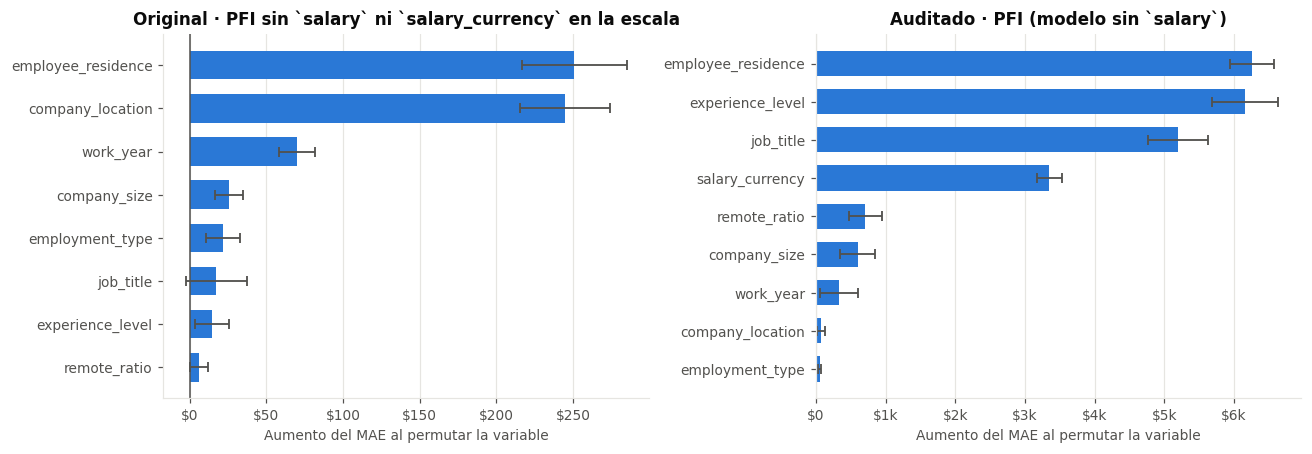

,Original,Auditado
variable,,
employee_residence,$251,"$6,257"
experience_level,$15,"$6,159"
job_title,$17,"$5,200"
salary_currency,"$9,922","$3,351"
remote_ratio,$6,$706
company_size,$26,$601
work_year,$70,$329
company_location,$245,$70
employment_type,$22,$55


In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

resto_original = importancias[~importancias["variable"].isin(["salary", "salary_currency"])]
grafico_pfi(resto_original, ax1,
            "Original · PFI sin `salary` ni `salary_currency` en la escala")
grafico_pfi(auditado["pfi"], ax2, "Auditado · PFI (modelo sin `salary`)")

plt.tight_layout()
plt.show()

lado_a_lado = (importancias.set_index("variable")[["importancia"]]
               .rename(columns={"importancia": "Original"})
               .join(auditado["pfi"].set_index("variable")[["importancia"]]
                     .rename(columns={"importancia": "Auditado"}), how="outer")
               .sort_values("Auditado", ascending=False))
lado_a_lado.style.format("${:,.0f}", na_rep="— (eliminada)")

**OBSERVACIONES**
- El análisis de PFI muestra resultados acorde a lo esperado: el sueldo depende en gran medida de `employee_residence` (o lo que es lo mismo, del lugar de residencia de la companía - hay países que pagan mejores salarios que otros, o incluso ciudades dentro de un mismo país simplemente porque el costo de vida es distinto), del `experience_level` (mayor expertise, mayor salario) y del `job_title` (qué posición).
- `company_location`tiene baja importancia, pero porque es redundante con `employee_residence`.

### 6.5 Razonabilidad del comportamiento

Dos verificaciones sobre el modelo auditado: que las contribuciones tengan la **dirección**
correcta, y que la redundancia geográfica de **H2** se comporte como se predijo.

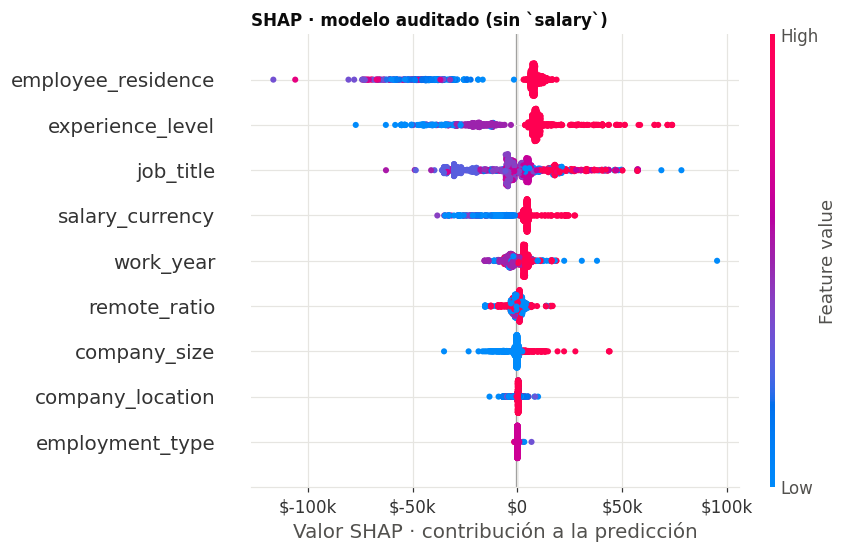

Contribución SHAP media de experience_level:
  EN · Junior          $  -40,233
  MI · Semi-senior     $  -19,412
  SE · Senior          $   +9,927
  EX · Ejecutivo       $  +48,480


In [32]:
explainer_aud = shap.TreeExplainer(auditado["modelo"])
sv_aud = explainer_aud(auditado["X_test"])

plt.figure()
shap.plots.beeswarm(sv_aud, max_display=9, show=False)
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_dolares))
ax.set_xlabel("Valor SHAP · contribución a la predicción")
plt.title("SHAP · modelo auditado (sin `salary`)", fontsize=11,
          fontweight="bold", color=TINTA, loc="left")
plt.tight_layout()
plt.show()

# Dirección de la contribución de la seniority: debería crecer de EN a EX
i_exp = list(auditado["X_test"].columns).index("experience_level")
efecto = (pd.DataFrame({"experience_level": X_test["experience_level"].values,
                        "SHAP": sv_aud.values[:, i_exp]})
            .groupby("experience_level")["SHAP"].mean()
            .reindex(ORDEN_EXP))
print("Contribución SHAP media de experience_level:")
for nivel, val in efecto.items():
    print(f"  {ETIQUETAS_EXP[nivel]:20s} ${val:+9,.0f}")

**OBSERVACIONES**
- Queda claro que el `experience_level` juega el rol esperado en el modelo curado.

In [33]:
# H2: si la geografía está duplicada, al quitar `salary_currency` la performance no debería
# moverse y `company_location` debería absorber parte de la importancia liberada.
sin_moneda = entrenar(["salary", "salary_currency"], "Sin `salary` ni `salary_currency`")

print("Performance en test")
for nombre, p in [("Sin `salary`", auditado["pred"]),
                  ("Sin `salary` ni `salary_currency`", sin_moneda["pred"])]:
    m = metricas(y_test, p)
    print(f"  {nombre:36s} MAE ${m['MAE']:,.0f}   R2 {m['R2']:.3f}")

print("\nImportancia de la dimensión geográfica")
geo = ["employee_residence", "company_location", "salary_currency"]
tabla_geo = (auditado["pfi"].set_index("variable")["importancia"].reindex(geo)
             .to_frame("Sin `salary`")
             .join(sin_moneda["pfi"].set_index("variable")["importancia"]
                   .reindex(geo).to_frame("Sin ambas")))
tabla_geo.style.format("${:,.0f}", na_rep="— (eliminada)")

Performance en test
  Sin `salary`                         MAE $36,407   R2 0.359
  Sin `salary` ni `salary_currency`    MAE $36,752   R2 0.360

Importancia de la dimensión geográfica


,Sin `salary`,Sin ambas
variable,,
employee_residence,"$6,257","$8,212"
company_location,$70,"$1,321"
salary_currency,"$3,351",— (eliminada)


**OBSERVACIONES**
- Se verifica que `salary_currency` no tiene implicancia en la performance porque es redundante con `company_location`.

- Eliminar `salary_currency`transfiere prácticamente toda su importancia a `employee_residence` y a `company_location` que tienen misma información en esencia.

**OBSERVACIONES FINALES**

**Performance.** El R² cae de **0,930 a 0,359** y el MAE sube de **$1.929 a $36.407**. 
El modelo curado sigue siendo claramente mejor que el baseline de la mediana
($48.412 de MAE), o sea que aprendió señal real — sólo que la señal real explica cerca de
un tercio de la varianza.

**Importancias.** El ranking pasa a ser interpretable y coherente con el EDA:

| | Original | Auditado |
|---|---:|---:|
| `employee_residence` | $251 | **$6.257** |
| `experience_level` | $15 | **$6.159** |
| `job_title` | $17 | **$5.200** |
| `salary_currency` | $9.922 | $3.351 |

`experience_level` pasa de $15 (indistinguible de cero) a $6.159, y `job_title` de $17 a
$5.200. **H3 queda resuelto**: las variables que el EDA señalaba como relevantes ahora
aparecen arriba, y lo hacen por sí solas, no por construcción.

**Razonabilidad.** La contribución SHAP media de `experience_level` crece de forma
monótona de EN a EX, es decir en la dirección correcta y con la magnitud esperable — lo
contrario del −$278 que un *Senior* recibía en el modelo original.

**Sobre H2 (redundancia).** La verificación confirma la hipótesis en los dos frentes:
- Quitar `salary_currency` no cambia la performance (R² 0,359 → 0,360, MAE $36.407 →
  $36.752). Su importancia de $9.922 en el modelo original provenía enteramente de
  ayudar a decodificar `salary`, como variable propia no aporta nada que la geografía no
  tenga ya.
- Al quitarla, `employee_residence` sube de $6.257 a **$8.212** y `company_location` salta
  de $70 a **$1.321**: la importancia no desaparece, se **redistribuye** entre las
  variables que codifican la misma información.

**CONCLUSIONES FINALES**

1. El modelo original no predecía salarios: leía `salary`, una copia del target que no
   existiría al momento de predecir. Ninguna métrica de performance lo habría revelado —
   sólo la interpretabilidad, y la sospecha nació de mirar las variables, no los números.
2. Una correlación de Pearson de **−0,02** convivía con un leakage total. Una correlación
   baja no es evidencia de ausencia de leakage. Es condición necesaria pero no suficiente.
3. El PFI reparte la importancia entre variables redundantes y por eso las subestima: hay
   que leerlo junto con una matriz de asociación, nunca aislado.
4. El modelo auditado (R² 0,36) es mucho peor en el papel y mucho más útil en la práctica.
   Para mejorarlo habría que sumar variables que hoy no están —industria, años de
   experiencia concretos, tamaño del equipo, nivel dentro de la banda salarial—, no
   ajustar hiperparámetros.